In [1]:
import numpy as np
import matplotlib.pyplot as plt
import string

import jax.numpy as jnp
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_device", jax.devices("cpu")[0])

# Import your optimization and plotting utilities
from optimization_core import build_jsa_grid, scaled_gaussian_jsa_vectorized_rsvd

from tensorrsvd import ho_rsvd

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
# ---------------------------------------------------------
# 1. Experiment parameters
# ---------------------------------------------------------

# Parameters for the multivariate normal distribution
n = 80  # Number of points in the frequency grid nxnxn
d = 3  # Dimensionality of the problem
mean = jnp.zeros(d)  # Mean
x_lim = 4  # Limits in x and y ax0is for plotting

# # Sweep parameters
n_steps = 4  # Number of steps in the sweep
rho_values = jnp.linspace(
    -0.49, 0.99, n_steps
)  # rho_values are the correlation coefficients in the correlation matrix

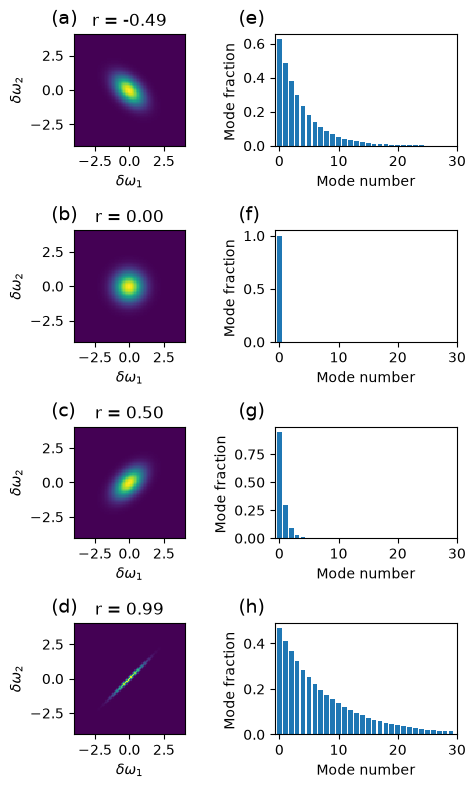

In [3]:
n_col = 2  # Number of columns in the figure
fig, axes = plt.subplots(
    len(rho_values), n_col, figsize=(2.5 * n_col, n_col * len(rho_values))
)
axes = np.atleast_2d(axes)
x = jnp.linspace(-x_lim, x_lim, n)

# Generate labels: a, b, c, ...
labels = list(string.ascii_lowercase)


for i, rho_value in enumerate(rho_values):
    _, jsa_data = build_jsa_grid(n, mean, rho_value, x_lim)

    # Random SVD
    f = scaled_gaussian_jsa_vectorized_rsvd(r=rho_value, mean=mean, x_lim=x_lim)

    rank = 30
    U_list, S_list = ho_rsvd(
        tensor=f,
        tensor_shape=(n,) * d,
        dtype=jnp.float64,
        rank=rank,
        num_oversamples=10,
        num_power_iterations=2,
        num_idxs=d,
        backend="jax",
    )

    s = S_list[0] / jnp.linalg.norm(S_list[0])

    # jsa_flat=jnp.reshape(jsa_data,(n,n**(d-1)))
    # u, s, vt = jax.scipy.linalg.svd(jsa_flat, full_matrices=False)

    jsa_norm = jsa_data / jnp.linalg.norm(jsa_data)
    jsa_proj = jnp.sum(jnp.square(jnp.abs(jsa_norm)), axis=0)
    ax0 = axes[i, 0]
    im = ax0.pcolor(x, x, jsa_proj, rasterized=True)
    ax0.set_box_aspect(1)
    ax0.set_xlabel(r"$\delta\omega_{1}$")
    ax0.set_ylabel(r"$\delta\omega_{2}$")
    ax0.set_title(f"r = {rho_value:.2f}")

    # compute label index for column-major order
    j = 0
    label_idx = i + j * len(rho_values)
    # Add label outside the plot
    ax0.text(
        -0.2,
        1.05,
        f"({labels[label_idx]})",
        transform=ax0.transAxes,
        fontsize=14,
        va="bottom",
        ha="left",
    )

    xbar = np.arange(0, len(s))

    ax1 = axes[i, 1]
    ax1.bar(xbar, s / np.linalg.norm(s))
    ax1.set_xlabel(r"Mode number")
    ax1.set_ylabel(r"Mode fraction ")
    ax1.set_xlim(-0.75, 30)

    j = 1
    label_idx = i + j * len(rho_values)
    # Add label (next letter)
    ax1.text(
        -0.2,
        1.05,
        f"({labels[label_idx]})",
        transform=ax1.transAxes,
        fontsize=14,
        va="bottom",
        ha="left",
    )
    label_idx += 1

    # Clear memory
    del jsa_data, jsa_norm, jsa_proj
    jax.clear_caches()

plt.tight_layout()
plt.savefig("proj_mode_decomp.pdf", dpi=300, bbox_inches="tight")
plt.show()